In [ ]:
# %pip install nutpie
%pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 92.6 MB/s eta 0:00:00:00:010:01


In [26]:
import requests
import pandas as pd
import numpy as np
import pytensor.tensor as pt
import time


from sklearn.preprocessing import StandardScaler, OneHotEncoder, minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

import pymc as pm
import arviz as az

import nutpie

import gurobipy as gp
from gurobipy import GRB


# FPL API Fetch


In [4]:
def find_my_leagues(manager_id):
    """
    Finds all league IDs (Classic and H2H) for a given manager.
    Use this to discover your H2H_LEAGUE_ID.
    """
    url = f"https://fantasy.premierleague.com/api/entry/{manager_id}/"
    print(f"Searching leagues for Manager {manager_id}...")

    try:
        r = requests.get(url)
        if r.status_code != 200:
            print(f"Failed to fetch data for manager {manager_id}")
            return

        data = r.json()
        leagues = data.get('leagues', {})

        print("\n--- H2H Leagues ---")
        for league in leagues.get('h2h', []):
            print(f"Name: {league['name']} | ID: {league['id']}")

        # print("\n--- Classic Leagues ---")
        # for league in leagues.get('classic', []):
        #     print(f"Name: {league['name']} | ID: {league['id']}")

    except Exception as e:
        print(f"Error: {e}")

def fetch_h2h_opponent(manager_id, league_id, gameweek):
    """
    Given a manager ID and H2H league ID, finds the opponent's manager ID
    by iterating through all pages of the matches endpoint.
    """
    page = 1
    print(f"Searching for H2H opponent for Manager {manager_id} in GW {gameweek}...")

    while True:
        url = f"https://fantasy.premierleague.com/api/leagues-h2h-matches/league/{league_id}/?page={page}&event={gameweek}"
        try:
            r = requests.get(url)
            if r.status_code != 200:
                print(f"Error fetching page {page}. Status: {r.status_code}")
                break

            data = r.json()
            matches = data.get('results', [])

            if not matches:
                break

            for match in matches:
                if match['entry_1_entry'] == manager_id:
                    return match['entry_2_entry']
                elif match['entry_2_entry'] == manager_id:
                    return match['entry_1_entry']

            if not data.get('has_next'):
                break

            page += 1
            time.sleep(0.2) # Avoid hitting rate limits during pagination
        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    print("Match not found in any of the league pages.")
    return None


def fetch_manager_history(manager_id, current_gw):
    """
    Fetches the historical team selections (picks) for a specific FPL manager.

    Args:
        manager_id (int): The unique ID of the FPL manager.
        current_gw (int): The most recent completed Gameweek.

    Returns:
        pd.DataFrame: A long-format DataFrame containing player IDs,
                      positions (starter/bench), and captaincy per GW.
    """
    base_url = "https://fantasy.premierleague.com/api/entry/{}/event/{}/picks/"
    all_picks = []
    managers = []

    print(f"Fetching history for Manager {manager_id}...")

    for gw in range(1, current_gw + 1):
        url = base_url.format(manager_id, gw)
        try:
            response = requests.get(url)

            # Rate limiting safety
            if response.status_code == 429:
                print("Rate limit hit. Sleeping for 10 seconds...")
                time.sleep(10)
                response = requests.get(url)

            if response.status_code != 200:
                print(f"Skipping GW {gw}: Status {response.status_code}")
                continue

            data = response.json()
            managers.append({
                'picks': data['picks'],
                'manager_id': manager_id,
                'round': gw,
                'total_points': data['entry_history']['points'],
                'points_on_bench': data['entry_history']['points_on_bench']
            })
            for pick in data['picks']:
                all_picks.append({
                    'manager_id': manager_id,
                    'round': gw,
                    'fpl_id': pick['element'],
                    'position_in_team': pick['position'], # 1-11 are starters, 12-15 bench
                    'multiplier': pick['multiplier'],      # 2 or 3 for captain/TC, 0 for bench
                    'is_captain': pick['is_captain'],
                    'is_vice_captain': pick['is_vice_captain'],
                    'total_points': data['entry_history']['points'],
                    'points_on_bench': data['entry_history']['points_on_bench']
                })

            # Small sleep to be polite to the API
            time.sleep(0.5)

        except Exception as e:
            print(f"Error fetching GW {gw}: {e}")

    df = pd.DataFrame(all_picks)
    manager_df = pd.DataFrame(managers)

    # Add a binary 'is_starter' column for easier modeling
    df['is_starter'] = df['multiplier'] > 0

    return df, manager_df

def get_current_gameweek():
    """Returns the current gameweek ID from the FPL bootstrap-static API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    r = requests.get(url).json()
    for event in r['events']:
        if event['is_current']:
            return event['id']
    return 1


In [5]:
manager_id = 438682 # Example ID (Overall league is usually huge, use a mini-league ID)
league_ids = find_my_leagues(manager_id)
print(league_ids)

Searching leagues for Manager 438682...

--- H2H Leagues ---
Name: EPL-DIEHARDS 2025/26 | ID: 69646
Name: EPL PUNDITS LEAGUE H2H 2025/26 | ID: 117506
Name: Kandanda H2H 2025/26 | ID: 125075
Name: Fantasy experts 25/26🟢 | ID: 126202
Name: H2H - Undefined League 25/26 | ID: 685131
None


In [6]:
OPPONENT_ID = fetch_h2h_opponent(438682, 117506, 23)

latest_gw = get_current_gameweek()

# Fetch all picks from GW1 to now
history_df, hist_manager = fetch_manager_history(OPPONENT_ID, latest_gw)
my_history_df, my_hist_manager = fetch_manager_history(manager_id, latest_gw)

# Save to CSV for the Dirichlet model
filename = f"manager_{OPPONENT_ID}_history.csv"
history_df.to_csv(filename, index=False)

print(f"Successfully saved {len(history_df)} picks to {filename}")
# print(history_df.head(15)) # Show the first team (GW1)
history_df

Searching for H2H opponent for Manager 438682 in GW 23...
Fetching history for Manager 435495...
Fetching history for Manager 438682...
Successfully saved 345 picks to manager_435495_history.csv


,manager_id,round,fpl_id,position_in_team,multiplier,is_captain,is_vice_captain,total_points,points_on_bench,is_starter
0,435495,1,502,1,1,False,False,70,10,True
1,435495,1,477,2,1,False,False,70,10,True
2,435495,1,507,3,1,False,False,70,10,True
3,435495,1,575,4,1,False,False,70,10,True
4,435495,1,582,5,1,False,False,70,10,True
...,...,...,...,...,...,...,...,...,...,...
340,435495,23,430,11,2,True,False,43,9,True
341,435495,23,470,12,0,False,False,43,9,False
342,435495,23,488,13,0,False,False,43,9,False
343,435495,23,694,14,0,False,False,43,9,False


In [21]:

hist_manager['selections'] = hist_manager.apply(lambda row: [pick['element'] for pick in row['picks']], axis=1)
my_hist_manager['selections'] = my_hist_manager.apply(lambda row: [pick['element'] for pick in row['picks']], axis=1)
# hist_manager['round'] = hist_manager['round'].values
my_hist_manager

,picks,manager_id,round,total_points,points_on_bench,selections
0,"[{'element': 220, 'position': 1, 'multiplier':...",438682,1,59,12,"[220, 145, 568, 441, 235, 384, 582, 119, 249, ..."
1,"[{'element': 220, 'position': 1, 'multiplier':...",438682,2,41,13,"[220, 187, 145, 441, 242, 582, 427, 119, 64, 2..."
2,"[{'element': 220, 'position': 1, 'multiplier':...",438682,3,59,21,"[220, 145, 187, 568, 384, 427, 119, 582, 64, 2..."
3,"[{'element': 253, 'position': 1, 'multiplier':...",438682,4,67,5,"[253, 72, 256, 348, 266, 381, 419, 82, 661, 28..."
4,"[{'element': 101, 'position': 1, 'multiplier':...",438682,5,50,2,"[101, 72, 256, 348, 266, 381, 419, 82, 661, 28..."
5,"[{'element': 101, 'position': 1, 'multiplier':...",438682,6,72,14,"[101, 256, 72, 348, 82, 119, 419, 266, 242, 28..."
6,"[{'element': 101, 'position': 1, 'multiplier':...",438682,7,67,10,"[101, 145, 72, 348, 82, 119, 419, 266, 666, 43..."
7,"[{'element': 253, 'position': 1, 'multiplier':...",438682,8,76,10,"[253, 145, 348, 256, 82, 119, 266, 582, 624, 4..."
8,"[{'element': 101, 'position': 1, 'multiplier':...",438682,9,71,7,"[101, 5, 348, 72, 82, 119, 266, 242, 430, 283,..."
9,"[{'element': 253, 'position': 1, 'multiplier':...",438682,10,83,6,"[253, 5, 348, 256, 82, 119, 384, 582, 430, 283..."


# FPL Data


In [7]:
data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
# data_25_26 = pd.read_csv('../Prediction with Affine PNN/data/rolled_player_data.csv')

gw = 6

In [8]:
cols = [

    'fpl_id', 'round',  'was_home', 'position', 'team_id', 'opponent_team_name',  'xP', # 'fpl_name', 'team_id', 'xP_next', #'form',  'value_form',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    #  'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm',  'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    #  'xA_3_ewm', 'xA_5_ewm',  'saves_3_ewm', 'saves_5_ewm',  'expected_assists_3_ewm', 'expected_assists_5_ewm',
    #  'assists_3_ewm', 'assists_5_ewm',  'goals_3_ewm', 'goals_5_ewm',
    # 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',  'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    #  'creativity_3_ewm', 'creativity_5_ewm',  'tackles_3_ewm', 'tackles_5_ewm',  'npxG_3_ewm', 'npxG_5_ewm',
    #  'value_3_ewm', 'value_5_ewm',  'goals_conceded_3_ewm', 'goals_conceded_5_ewm',  'ict_index_3_ewm',
    # 'ict_index_5_ewm',  'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',  'xG_3_ewm', 'xG_5_ewm',
    #  'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',  'influence_3_ewm',
    # 'influence_5_ewm',  'threat_3_ewm', 'threat_5_ewm',  'shots_3_ewm', 'shots_5_ewm',  'expected_goals_3_ewm',
    # 'expected_goals_5_ewm',  'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',  'transfers_in_3_ewm',
    # 'transfers_in_5_ewm',  'recoveries_3_ewm', 'recoveries_5_ewm',  'goals_scored_3_ewm', 'goals_scored_5_ewm',
    #  'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',  'minutes_3_ewm', 'minutes_5_ewm',
    # 'red_cards_3_ewm', 'red_cards_5_ewm',  'key_passes_3_ewm', 'key_passes_5_ewm',  'xP_3_ewm', 'xP_5_ewm',  'form_3_ewm',
    # 'form_5_ewm',  'clean_sheets_3_ewm', 'clean_sheets_5_ewm',  'npg_3_ewm', 'npg_5_ewm',  'starts_3_ewm',
    # 'starts_5_ewm',  'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm',
    # 'ownership_change_3_ewm', 'ownership_change_5_ewm',  'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm',
    # 'pts_bonus_3_ewm', 'pts_bonus_5_ewm',  'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm',
    # 'transfers_out_3_ewm', 'transfers_out_5_ewm',  'xGChain_3_ewm', 'xGChain_5_ewm',  'strength_3_ewm', 'strength_5_ewm',
    #  'selected_3_ewm', 'selected_5_ewm',  'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',
    #  'xGBuildup_3_ewm', 'xGBuildup_5_ewm',


    'expected_goals_conceded_1_ewm', 'yellow_cards_1_ewm', 'xA_1_ewm', 'saves_1_ewm', 'expected_assists_1_ewm', 'assists_1_ewm', 'goals_1_ewm',
    'expected_goal_involvements_1_ewm', 'strength_overall_home_1_ewm', 'creativity_1_ewm', 'tackles_1_ewm', 'npxG_1_ewm', 'value_1_ewm', 'goals_conceded_1_ewm',
    'ict_index_1_ewm', 'strength_defence_away_1_ewm', 'xG_1_ewm', 'clearances_blocks_interceptions_1_ewm', 'influence_1_ewm', 'threat_1_ewm', 'shots_1_ewm',
    'expected_goals_1_ewm', 'strength_overall_away_1_ewm', 'transfers_in_1_ewm', 'recoveries_1_ewm', 'goals_scored_1_ewm', 'selected_by_percent_1_ewm',
    'minutes_1_ewm', 'red_cards_1_ewm', 'key_passes_1_ewm', 'xP_1_ewm', 'form_1_ewm', 'clean_sheets_1_ewm', 'npg_1_ewm', 'starts_1_ewm',
    'percenatge_net_transfers_1_ewm', 'ownership_change_1_ewm', 'strength_attack_away_1_ewm', 'pts_bonus_1_ewm', 'strength_attack_home_1_ewm', 'transfers_out_1_ewm',
    'xGChain_1_ewm', 'strength_1_ewm', 'selected_1_ewm', 'strength_defence_home_1_ewm', 'xGBuildup_1_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

feats = [
    # 'fpl_id', 'round',  #'position', #'team', 'opponent_team_name', #'was_home', #'xP', # 'fpl_name', 'team_id', 'xP_next', #'form',  'value_form',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,
    'expected_goals_conceded_1_ewm', 'yellow_cards_1_ewm', 'xA_1_ewm', 'saves_1_ewm', 'expected_assists_1_ewm', 'assists_1_ewm', 'goals_1_ewm',
    'expected_goal_involvements_1_ewm', 'strength_overall_home_1_ewm', 'creativity_1_ewm', 'tackles_1_ewm', 'npxG_1_ewm', 'value_1_ewm', 'goals_conceded_1_ewm',
    'ict_index_1_ewm', 'strength_defence_away_1_ewm', 'xG_1_ewm', 'clearances_blocks_interceptions_1_ewm', 'influence_1_ewm', 'threat_1_ewm', 'shots_1_ewm',
    'expected_goals_1_ewm', 'strength_overall_away_1_ewm', 'transfers_in_1_ewm', 'recoveries_1_ewm', 'goals_scored_1_ewm', 'selected_by_percent_1_ewm',
    'minutes_1_ewm', 'red_cards_1_ewm', 'key_passes_1_ewm', 'xP_1_ewm', 'form_1_ewm', 'clean_sheets_1_ewm', 'npg_1_ewm', 'starts_1_ewm',
    'percenatge_net_transfers_1_ewm', 'ownership_change_1_ewm', 'strength_attack_away_1_ewm', 'pts_bonus_1_ewm', 'strength_attack_home_1_ewm', 'transfers_out_1_ewm',
    'xGChain_1_ewm', 'strength_1_ewm', 'selected_1_ewm', 'strength_defence_home_1_ewm', 'xGBuildup_1_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',
    'was_home_False', 'was_home_True'
]

gk_cols = [
    # 'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'yellow_cards_5_ewm', 'saves_5_ewm', 'strength_overall_home_5_ewm', 'creativity_5_ewm', 'value_5_ewm', 'goals_conceded_5_ewm', 'ict_index_5_ewm',
    'strength_defence_away_5_ewm', 'influence_5_ewm', 'threat_5_ewm', 'strength_overall_away_5_ewm', 'transfers_in_5_ewm', 'selected_by_percent_5_ewm',
    'minutes_5_ewm', 'red_cards_5_ewm', 'xP_5_ewm', 'form_5_ewm', 'clean_sheets_5_ewm', 'starts_5_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_5_ewm',
    'strength_attack_away_5_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_5_ewm', 'transfers_out_5_ewm', 'strength_5_ewm', 'selected_5_ewm',
    'strength_defence_home_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',

    'was_home_False', 'was_home_True'
    ]

def_mid_cols = [

    # 'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    'expected_goals_conceded_5_ewm', 'yellow_cards_5_ewm', 'xA_5_ewm', 'expected_assists_5_ewm', 'assists_5_ewm', 'goals_5_ewm', 'expected_goal_involvements_5_ewm',
    'strength_overall_home_5_ewm', 'creativity_5_ewm', 'tackles_5_ewm', 'npxG_5_ewm', 'value_5_ewm', 'goals_conceded_5_ewm', 'ict_index_5_ewm',
    'strength_defence_away_5_ewm', 'xG_5_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_5_ewm', 'threat_5_ewm', 'shots_5_ewm', 'expected_goals_5_ewm',
    'strength_overall_away_5_ewm', 'transfers_in_5_ewm', 'recoveries_5_ewm', 'goals_scored_5_ewm', 'selected_by_percent_5_ewm', 'minutes_5_ewm', 'red_cards_5_ewm',
    'key_passes_5_ewm', 'xP_5_ewm', 'form_5_ewm', 'clean_sheets_5_ewm', 'npg_5_ewm', 'starts_5_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_5_ewm',
    'strength_attack_away_5_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_5_ewm', 'transfers_out_5_ewm', 'xGChain_5_ewm', 'strength_5_ewm', 'selected_5_ewm',
    'strength_defence_home_5_ewm', 'xGBuildup_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',

    'was_home_False', 'was_home_True'
    ]

fwd_cols = [

    # 'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    'xA_5_ewm', 'expected_assists_5_ewm', 'assists_5_ewm', 'goals_5_ewm', 'expected_goal_involvements_5_ewm', 'creativity_5_ewm', 'tackles_5_ewm', 'npxG_5_ewm',
    'value_5_ewm', 'ict_index_5_ewm', 'xG_5_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_5_ewm', 'threat_5_ewm', 'shots_5_ewm', 'expected_goals_5_ewm',
    'transfers_in_5_ewm', 'recoveries_5_ewm', 'goals_scored_5_ewm', 'selected_by_percent_5_ewm', 'minutes_5_ewm', 'red_cards_5_ewm', 'key_passes_5_ewm', 'xP_5_ewm',
    'form_5_ewm', 'npg_5_ewm', 'starts_5_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_5_ewm', 'pts_bonus_5_ewm', 'transfers_out_5_ewm', 'xGChain_5_ewm',
    'selected_5_ewm', 'xGBuildup_5_ewm', 'strength_5_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_5_ewm', 'strength_attack_home_5_ewm',
    'strength_attack_away_5_ewm', 'strength_overall_away_5_ewm', 'strength_overall_home_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',
     'was_home_False', 'was_home_True'

    ]

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)


In [9]:

# hist_data = data_25_26[data_25_26['minutes_3'] > 15]
data = data_25_26[(data_25_26['round'] < gw)].copy()
data_next = data_25_26[data_25_26['round'] == gw].copy()

# data_25_26 = pd.concat([hist_data, tar_data])

active_data = data[cols].copy()
active_data_ = active_data.copy()

active_data_next = data_next[cols].copy()

CATEGORICAL_COLS = ['was_home'] #, 'team',  'opponent_team_name']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

encoded_next_df = pd.DataFrame(
    encoder.transform(active_data_next[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_next.index
)

cols_ = [*cols, *encoded_cols]
# Combine with numerical data
active_data_ = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)
active_data_next_ = pd.concat([active_data_next, encoded_next_df], axis=1).drop(columns=CATEGORICAL_COLS)

active_data_next_.loc[:, 'value'] = active_data_next_['value']/10
active_data_next_.loc[:, 'selected_by_percent'] = active_data_next_['selected_by_percent']/100

active_data_.loc[:, 'value'] = active_data_['value']/10
active_data_.loc[:, 'selected_by_percent'] = active_data_['selected_by_percent']/100
active_data_

,fpl_id,round,position,team_id,opponent_team_name,xP,selected_by_percent,value,transfers_in,transfers_out,...,xGChain_1_ewm,strength_1_ewm,selected_1_ewm,strength_defence_home_1_ewm,xGBuildup_1_ewm,opp_elo,opp_clean_sheets,opp_strength,was_home_False,was_home_True
0,1.0,1,GK,1.0,Manchester United,4.2,0.369,5.5,3072169.0,1125554.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
1,1.0,2,GK,1.0,Arsenal,9.0,0.215,5.5,354674.0,120510.0,...,0.086901,4.0,1531911.0,1290.0,0.086901,2037.0,1.0,4.0,0.0,1.0
2,1.0,3,GK,1.0,Liverpool,5.5,0.218,5.5,108234.0,114694.0,...,0.204982,4.0,2284634.0,1290.0,0.204982,1993.0,1.0,5.0,1.0,0.0
3,1.0,4,GK,1.0,Arsenal,6.5,0.235,5.5,283354.0,128620.0,...,0.108124,4.0,2406964.0,1290.0,0.058624,2037.0,1.0,4.0,0.0,1.0
4,1.0,5,GK,1.0,Arsenal,4.0,0.240,5.5,160846.0,111953.0,...,0.895559,4.0,2765759.0,1290.0,0.895559,2037.0,0.0,4.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6596,732.0,4,FWD,8.0,Crystal Palace,2.3,0.000,5.5,1809.0,345.0,...,0.000000,0.0,0.0,0.0,0.000000,1869.0,1.0,3.0,0.0,1.0
6623,734.0,4,MID,16.0,Arsenal,1.6,0.000,6.0,746.0,197.0,...,0.000000,0.0,0.0,0.0,0.000000,2037.0,1.0,4.0,1.0,0.0
6624,734.0,5,MID,16.0,Burnley,1.5,0.000,6.0,752.0,264.0,...,0.019289,3.0,613.0,1180.0,0.019289,1733.0,0.0,2.0,1.0,0.0
6642,736.0,4,GK,13.0,Manchester City,4.5,0.017,5.5,168077.0,15792.0,...,0.000000,0.0,0.0,0.0,0.000000,1850.0,0.0,3.0,0.0,1.0


In [10]:
gk_data = active_data_[(active_data_['position_GK'] == 1) & (active_data_['round'] <= gw)]#[gk_cols] #.drop(['position'], axis=1)
def_data = active_data_[(active_data_['position_DEF'] == 1) & (active_data_['round'] <= gw)]#[def_mid_cols]#.drop(['position'], axis=1)
mid_data = active_data_[(active_data_['position_MID'] == 1) & (active_data_['round'] <= gw)]#[def_mid_cols]#.drop(['position'], axis=1)
fwd_data = active_data_[(active_data_['position_FWD'] == 1) & (active_data_['round'] <= gw)]#[fwd_cols]#.drop(['position'], axis=1)

gk_ids = gk_data['fpl_id'].unique().tolist()
def_ids = def_data['fpl_id'].unique().tolist()
mid_ids = mid_data['fpl_id'].unique().tolist()
fwd_ids = fwd_data['fpl_id'].unique().tolist()

gk_data_num = gk_data.drop(columns=['fpl_id', 'round', 'xP'])
def_data_num = def_data.drop(columns=['fpl_id', 'round', 'xP'])
mid_data_num = mid_data.drop(columns=['fpl_id', 'round', 'xP'])
fwd_data_num = fwd_data.drop(columns=['fpl_id', 'round', 'xP'])

gk_data_num_scaled = pd.DataFrame(minmax_scale(gk_data_num), columns=gk_data_num.columns, index=gk_data_num.index)
def_data_num_scaled = pd.DataFrame(minmax_scale(def_data_num), columns=def_data_num.columns, index=def_data_num.index)
mid_data_num_scaled = pd.DataFrame(minmax_scale(mid_data_num), columns=mid_data_num.columns, index=mid_data_num.index)
fwd_data_num_scaled = pd.DataFrame(minmax_scale(fwd_data_num), columns=fwd_data_num.columns, index=fwd_data_num.index)

# gk_data_scaled = pd.concat([gk_data[['fpl_id', 'round']], gk_data_num_scaled], axis=1)
# def_data_scaled = pd.concat([def_data[['fpl_id', 'round']], def_data_num_scaled], axis=1)
# mid_data_scaled = pd.concat([mid_data[['fpl_id', 'round']], mid_data_num_scaled], axis=1)
# fwd_data_scaled = pd.concat([fwd_data[['fpl_id', 'round']], fwd_data_num_scaled], axis=1)

# Selection percentages
gk_select_by = gk_data_num_scaled['selected_by_percent']
def_select_by = def_data_num_scaled['selected_by_percent']
mid_select_by = mid_data_num_scaled['selected_by_percent']
fwd_select_by = fwd_data_num_scaled['selected_by_percent']


# Normalise the select_percts to get the working probs
gk_probs = np.clip(gk_select_by/np.sum(gk_select_by), 1e-5, 1.0)
def_probs = np.clip(def_select_by/np.sum(def_select_by), 1e-5, 1.0)
mid_probs = np.clip(mid_select_by/np.sum(mid_select_by), 1e-5, 1.0)
fwd_probs = np.clip(fwd_select_by/np.sum(fwd_select_by), 1e-5, 1.0)


gk_data_scaled = gk_data_num_scaled.drop(columns='selected_by_percent')
def_data_scaled = def_data_num_scaled.drop(columns='selected_by_percent')
mid_data_scaled = mid_data_num_scaled.drop(columns='selected_by_percent')
fwd_data_scaled = fwd_data_num_scaled.drop(columns='selected_by_percent')

gk_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = gk_data[['fpl_id', 'round', 'selected_by_percent']]
def_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = def_data[['fpl_id', 'round', 'selected_by_percent']]
mid_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = mid_data[['fpl_id', 'round', 'selected_by_percent']]
fwd_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = fwd_data[['fpl_id', 'round', 'selected_by_percent']]


hist_manager['gk_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in gk_ids ], axis=1)
hist_manager['def_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in def_ids ], axis=1)
hist_manager['mid_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in mid_ids ], axis=1)
hist_manager['fwd_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in fwd_ids ], axis=1)
hist_manager

KeyError: 'position_GK'

# Get Betas


In [10]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

        # approx = pm.fit(n=2000, method='advi', progressbar=True)
        # trace = approx.sample(2000)

    return trace

In [11]:
# # Fit the model to get beta estimates
# trace_gk = fit_dirichlet_regression(gk_data_scaled, gk_probs)

# # Extract the mean of the beta posterior samples to use in Algorithm 1
# beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# # trace_gk
# az.plot_trace(trace_gk, combined=True)

# # Summary with R-hat, ESS, mean, sd, etc.
# summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
# summary

# Functions


In [10]:

def estimate_opponent_betas_with_market_prior(opponent_features, opponent_picks, market_ownership):
    """
    Fits a Dirichlet-Multinomial regression using market ownership as the prior.
    """
    T, N, K = opponent_features.shape
    market_prior = np.clip(market_ownership, 1e-5, 1.0)

    with pm.Model() as model:
        beta = pm.Normal("beta", mu=0, sigma=0.5, shape=K)
        market_offset = pt.log(market_prior)
        mu = market_offset + pt.dot(opponent_features, beta)
        alpha = pm.Deterministic("alpha", pt.exp(mu))

        # n is the total number of picks in the historical data (e.g., 11 or 15)
        pm.DirichletMultinomial(
            "obs",
            n=opponent_picks.sum(axis=1),
            a=alpha,
            observed=opponent_picks
        )

        trace = pm.sample(1000, tune=1000, target_accept=0.8)

    return trace

def prepare_feature_and_market_matrices(df, feature_cols):
    """
    Prepares the X matrix and the Market Prior matrix.
    """
    feature_cols.remove('fpl_id')
    rounds = sorted(df['round'].unique())
    players = sorted(map(int, df['fpl_id'].unique()))
    T, N, K = len(rounds), len(players), len(feature_cols)

    X = np.zeros((T, N, K))
    M = np.zeros((T, N))

    for t_idx, r in enumerate(rounds):
        week_df = df[df['round'] == r].set_index('fpl_id').reindex(players).fillna(0)
        X[t_idx, :, :] = week_df[feature_cols].values
        M[t_idx, :] = week_df['selected_by_percent'].values / 100.0

    return X, M, players

def get_opponent_stochastic_stats(next_gw_df, trace, n_simulations=1000):
    """
    Calculates stats using positional marginals to simulate a valid 15-man FPL squad.

    Args:
        next_gw_df: DataFrame with current GW features, xP, and 'position' column.
        trace: The Bayesian trace from the Dirichlet model.
    """
    beta_samples = trace.posterior["beta"].values.reshape(-1, trace.posterior["beta"].shape[-1])

    # Selection logic per position
    positions = {'GKP': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
    player_ids = next_gw_df.index.tolist()

    sim_scores = []
    ownership_counts = np.zeros(len(next_gw_df))

    for i in range(n_simulations):
        # 1. Sample one set of Betas from the posterior
        beta_sample = beta_samples[np.random.choice(len(beta_samples))]

        # 2. Predict Alphas
        # (Using the link: alpha = market_prior * exp(X * beta))
        log_market = np.log(np.clip(next_gw_df['selected_by_percent'].values / 100.0, 1e-5, 1.0))
        # Note: adjust this if feature_cols list isn't globally available or passed
        # Assuming features are in a specific subset of columns
        feature_vals = next_gw_df.drop(columns=['position', 'xP', 'selected_by_percent']).values
        alpha = np.exp(log_market + np.dot(feature_vals, beta_sample))

        full_team_idx = []

        # 3. Positional Sampling (Step 1 from the paper's Algorithm 4)
        for pos, count in positions.items():
            pos_mask = (next_gw_df['position'] == pos).values
            pos_alphas = alpha[pos_mask]
            pos_indices = np.where(pos_mask)[0]

            # Dirichlet draw for this position's probabilities
            p_pos = np.random.dirichlet(pos_alphas)

            # Sample the specific players for this position
            chosen = np.random.choice(pos_indices, size=count, p=p_pos/p_pos.sum(), replace=False)
            full_team_idx.extend(chosen)

        # 4. Score the Starting 11 (Simple heuristic: top 11 by xP)
        squad_xP = next_gw_df.iloc[full_team_idx].sort_values('xP', ascending=False)
        # In reality, FPL formation rules apply, but this is a solid benchmark estimate
        starting_11_score = squad_xP.iloc[:11]['xP'].sum()

        sim_scores.append(starting_11_score)
        ownership_counts[full_team_idx] += 1

    prob_owned = ownership_counts / n_simulations

    return {
        "opponent_mean": np.mean(sim_scores),
        "opponent_var": np.var(sim_scores),
        # Covariance based on 15-man squad ownership likelihood
        "player_covariances": prob_owned * next_gw_df['xP'].var()
    }



In [11]:
def prepare_data_matrices(feature_df, picks_df, feature_cols):
    """
    Transforms long-format FPL data into (T, N, K) matrices for modeling.

    Args:
        feature_df: DataFrame with columns ['round', 'fpl_id', 'selected_by_percent'] + feature_cols
        picks_df: DataFrame from scraper with columns ['round', 'fpl_id', 'is_starter']
        feature_cols: List of strings for the features to be used in the model.
    """
    rounds = sorted(feature_df['round'].unique())
    # Use all players present in the feature set as the universe (N)
    players = sorted(feature_df['fpl_id'].unique())
    # feature_cols.remove('fpl_id')
    # feature_cols.remove('round')

    T, N, K = len(rounds), len(players), len(feature_cols)

    X = np.zeros((T, N, K))
    M = np.zeros((T, N))
    Y = np.zeros((T, N), dtype=int)

    for t_idx, r in enumerate(rounds):
        # Subset features for this week
        week_feat = feature_df[feature_df['round'] == r].set_index('fpl_id').reindex(players).fillna(0)
        X[t_idx, :, :] = week_feat[feature_cols].values
        M[t_idx, :] = week_feat['selected_by_percent'].values / 100.0

        # Subset picks for this week
        week_picks = picks_df[picks_df['round'] == r]
        # Set 1 for players the manager actually selected
        picked_ids = week_picks[week_picks['is_starter'] == True]['fpl_id'].values
        for pid in picked_ids:
            if pid in players:
                p_idx = players.index(pid)
                Y[t_idx, p_idx] = 1

        # Y = [
        #         [
        #             1 if id_ in pick  else 0
        #             for id_ in players
        #         ]
        #         for pick in picks_df.values
        #     ]


    return X, M, Y, players

def estimate_opponent_betas_with_market_prior(opponent_features, opponent_picks, market_ownership, use_gpu=False):
    """
    Fits a Dirichlet-Multinomial regression using market ownership as the prior.
    Standardizes opponent_features internally to improve MCMC convergence.

    Args:
        opponent_features: (T_weeks, N_players, K_features) numpy array
        opponent_picks: (T_weeks, N_players) binary matrix (1 if picked, 0 otherwise)
        market_ownership: (T_weeks, N_players) market selection percentages [0, 1]
    """
    T, N, K = opponent_features.shape

    # Flatten to standardize across all player-weeks, then reshape back
    scaler = StandardScaler()
    flat_features = opponent_features.reshape(-1, K)
    scaled_features = scaler.fit_transform(flat_features).reshape(T, N, K)

    # Add epsilon to avoid log(0) issues in the link function
    market_prior = np.clip(market_ownership, 1e-5, 1.0)

    with pm.Model() as model:
        # Priors for the 'Deviation' coefficients
        beta = pm.Normal("beta", mu=0, sigma=0.5, shape=K)

        # Link Function: log(alpha) = log(market_prior) + X_scaled * beta
        market_offset = pt.log(market_prior)
        mu = market_offset + pt.dot(scaled_features, beta)
        alpha = pm.Deterministic("alpha", pt.exp(mu))

        # Likelihood: Dirichlet-Multinomial
        # n is the total number of picks in the historical data (usually 11 or 15)
        pm.DirichletMultinomial(
            "obs",
            n=opponent_picks.sum(axis=1),
            a=alpha,
            observed=opponent_picks
        )



        # Sample from the posterior
        if use_gpu:
            # Compiled with JAX backend for GPU/TPU acceleration
            compiled_model = nutpie.compile_pymc_model(model)
            trace = nutpie.sample(compiled_model, draws=1000, tune=1000)
        else:
            trace = pm.sample(1000, tune=1000, target_accept=0.8, progressbar=True)
        # # Sample from the posterior
        # trace = pm.sample(1000, tune=1000, target_accept=0.8, progressbar=True)

    return trace, scaler


def get_feature_importance(trace, feature_cols):
    """
    Calculates feature importance based on the posterior distribution of Betas.

    Returns:
        pd.DataFrame: Importance table with Mean, SD, and 'Significance'
                     (Probability of Direction).
    """
    # Extract beta samples from the trace
    beta_samples = trace.posterior["beta"].values.reshape(-1, len(feature_cols))

    importance_data = []
    for i, col in enumerate(feature_cols):
        samples = beta_samples[:, i]
        mean_val = np.mean(samples)
        # Probability of Direction: % of samples that have the same sign as the mean
        # A value near 1.0 indicates a very consistent/significant signal.
        if mean_val > 0:
            pd_val = np.mean(samples > 0)
        else:
            pd_val = np.mean(samples < 0)

        importance_data.append({
            'feature': col,
            'importance_score': np.abs(mean_val), # Strength of the shift
            'direction': 'positive' if mean_val > 0 else 'negative',
            'significance_pd': pd_val, # Bayesian equivalent of p-value
            'lower_hdi': np.percentile(samples, 3),
            'upper_hdi': np.percentile(samples, 97)
        })

    importance_df = pd.DataFrame(importance_data).sort_values('importance_score', ascending=False)
    return importance_df

def get_opponent_stochastic_stats(next_gw_df, trace, feature_cols, scaler, n_simulations=1000, stacking_prob=0.3):
    """
    Generates stochastic benchmark moments using the posterior behavior.
    """
    beta_samples = trace.posterior["beta"].values.reshape(-1, len(feature_cols))

    positions = {'GK': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
    num_players = len(next_gw_df)

    sim_scores = []
    ownership_matrix = np.zeros((n_simulations, num_players))

    market_prior = np.clip(next_gw_df['selected_by_percent'].values, 1e-5, 1.0)
    log_market = np.log(market_prior)

    X_next_raw = next_gw_df[feature_cols].values
    X_next_scaled = scaler.transform(X_next_raw)

    for i in range(n_simulations):
        beta_sample = beta_samples[np.random.choice(len(beta_samples))]
        # Using .eval() or keeping it in numpy for simulation speed
        mu_lin = np.dot(X_next_scaled, beta_sample)
        mu = log_market + np.clip(mu_lin, -8, 8)
        alpha = np.exp(mu)

        squad_idx = []
        is_stacking = np.random.rand() < stacking_prob

        for pos, count in positions.items():

            pos_mask = (next_gw_df['position'] == pos).values
            pos_indices = np.where(pos_mask)[0]
            pos_alphas = alpha[pos_mask]
            p_pos = np.random.dirichlet(pos_alphas)

            if is_stacking and pos == 'DEF' and len(squad_idx) > 0:
                existing_teams = next_gw_df.iloc[squad_idx]['team_id'].unique()
                stack_mask = next_gw_df.iloc[pos_indices]['team_id'].isin(existing_teams).values
                p_pos[stack_mask] *= 2.0

            chosen = np.random.choice(pos_indices, size=count, p=p_pos/p_pos.sum(), replace=False)
            squad_idx.extend(chosen)

        squad_df = next_gw_df.iloc[squad_idx]
        gk_idx = squad_df[squad_df['position'] == 'GK'].index[0]
        outfield_options = squad_df[squad_df['position'] != 'GK'].sort_values('xP', ascending=False)
        starting_xi_indices = [gk_idx] + outfield_options.index[:10].tolist()

        score = next_gw_df.loc[starting_xi_indices, 'xP'].sum()
        sim_scores.append(score)
        ownership_matrix[i, squad_idx] = 1

    return {
        "mean": np.mean(sim_scores),
        "variance": np.var(sim_scores),
        "cov_vector": np.array([np.cov(ownership_matrix[:, p], sim_scores)[0, 1] for p in range(num_players)]),
        "simulated_scores": sim_scores
    }

def estimate_player_covariance(history_df, current_player_ids):
    """
    Estimates a stable covariance matrix (Sigma) for player scores using Ledoit-Wolf shrinkage.

    Args:
        history_df (pd.DataFrame): Long-format points history.
                                   Must have ['round', 'fpl_id', 'total_points'].
        current_player_ids (list): The list of player IDs currently available/in your optimizer
                                   dataframe, to ensure the matrix rows/cols align.

    Returns:
        np.ndarray: N x N covariance matrix aligned with current_player_ids.
    """
    print(f"Estimating covariance for {len(current_player_ids)} players using Ledoit-Wolf...")

    # 1. Create a pivot table: Rows = Rounds, Columns = Players
    # We fill with 0 because a missing entry usually means the player didn't play (0 points)
    pivot_df = history_df.pivot(index='round', columns='fpl_id', values='xP').fillna(0)

    # 2. Reindex columns to match the current player pool
    # If a player has no history, they get a column of zeros
    pivot_df = pivot_df.reindex(columns=current_player_ids, fill_value=0)

    # 3. Fit Ledoit-Wolf Shrinkage
    # This shrinks the sample covariance toward a structured target,
    # making it invertible and stable for the Gurobi quadratic objective.
    lw = LedoitWolf()
    lw.fit(pivot_df)

    sigma = lw.covariance_

    # 4. Small stability check
    # Ensure the diagonal (variance) isn't zero for any player to prevent Gurobi issues
    min_var = 1e-6
    diag_indices = np.diag_indices_from(sigma)
    sigma[diag_indices] = np.maximum(sigma[diag_indices], min_var)

    return sigma

# Models


## GK


In [35]:
gk_feats = ['ict_index_5_ewm',
 'opp_strength',
 'red_cards_5_ewm',
 'opp_clean_sheets',
 'selected_by_percent_5_ewm',
 'clean_sheets_5_ewm',
 'goals_conceded_5_ewm',
 'value_5_ewm',
 'transfers_in_5_ewm',
 'minutes_5_ewm',
 'percenatge_net_transfers_5_ewm',
 'draw_prob',
 'creativity_5_ewm',
 'value',
 'ownership_change_5_ewm',
 'threat_5_ewm',
 'percenatge_net_transfers',
 'strength_defence_away_5_ewm',
 'strength_defence_home_5_ewm',
 'selected_by_percent',
 'transfers_in',
 'elo',
 'strength_overall_home_5_ewm',
 'opp_elo',
 'saves_5_ewm',
 'transfers_out_5_ewm',
 'strength_5_ewm',
 'lose_prob',
 'form_5_ewm']

In [36]:
gk_picks_df = hist_manager[hist_manager['round']< gw]['gk_picks']
X_gk, M_gk,Y_gk, players_gk = prepare_data_matrices(gk_data, gk_picks_df, gk_feats) #gk_cols)

gk_trace, gk_scaler = estimate_opponent_betas_with_market_prior(X_gk, M_gk,Y_gk, use_gpu=True)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.71,7
,2000,0,0.70,7
,2000,0,0.69,7
,2000,0,0.70,7
,2000,0,0.70,7
,2000,0,0.70,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.00,0.52,-0.89,1.02,0.0,0.01,16858.98,3958.08,1.00
beta[1],-0.00,0.51,-0.95,0.94,0.0,0.01,15619.03,4471.01,1.00
beta[2],-0.00,0.50,-0.96,0.93,0.0,0.01,18046.12,4540.89,1.00
beta[3],0.00,0.50,-0.97,0.91,0.0,0.01,16525.87,3890.81,1.00
beta[4],-0.00,0.48,-0.92,0.88,0.0,0.01,17843.35,4545.57,1.00
beta[5],-0.01,0.49,-0.92,0.91,0.0,0.01,18870.95,4200.70,1.00
beta[6],0.00,0.50,-0.99,0.91,0.0,0.01,16005.06,4302.65,1.00
beta[7],0.00,0.51,-0.97,0.95,0.0,0.01,18049.99,3931.17,1.00
beta[8],0.00,0.50,-0.91,0.99,0.0,0.01,17435.13,4237.93,1.00
beta[9],-0.00,0.51,-0.94,0.96,0.0,0.01,17822.20,4223.60,1.00


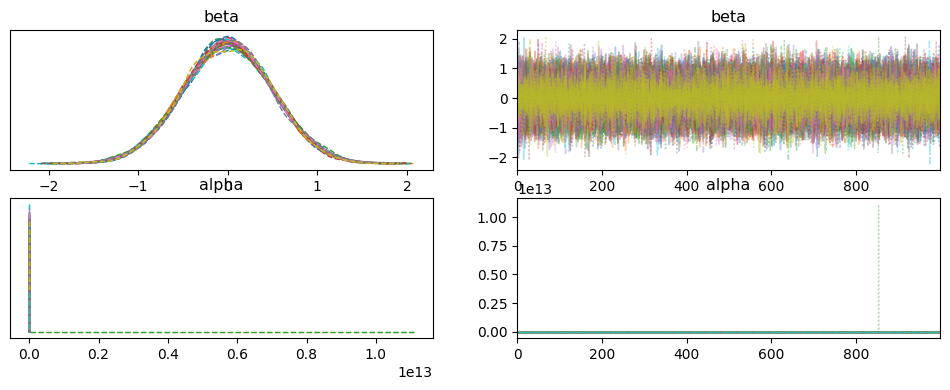

In [37]:
# trace_gk
az.plot_trace(gk_trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
gk_summary = az.summary(gk_trace, var_names=["beta"], round_to=2)
gk_summary

In [39]:
gk_feat_importance = get_feature_importance(gk_trace,gk_feats)#cols)#
gk_feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
5,clean_sheets_5_ewm,0.010741,negative,0.509500,-0.920108,0.911143
21,elo,0.004872,negative,0.501000,-0.941709,0.933689
16,percenatge_net_transfers,0.004551,positive,0.505667,-0.959218,0.970522
28,form_5_ewm,0.004422,negative,0.503167,-0.939532,0.910788
25,transfers_out_5_ewm,0.003845,positive,0.504833,-0.948039,0.942724
27,lose_prob,0.003636,positive,0.503000,-0.944470,0.964694
19,selected_by_percent,0.003126,negative,0.502833,-0.934345,0.932092
10,percenatge_net_transfers_5_ewm,0.002986,positive,0.498167,-0.939359,0.964452
7,value_5_ewm,0.002850,positive,0.503500,-0.956679,0.963667
13,value,0.002814,negative,0.502000,-0.933568,0.903752


In [33]:
gk_feats = gk_feat_importance[gk_feat_importance['significance_pd'] > .5]['feature'].values.tolist()

## DEF


In [47]:
def_picks_df = hist_manager[hist_manager['round']< gw]['def_picks']
X_def, M_def, Y_def, players_def = prepare_data_matrices(def_data, def_picks_df, def_mid_cols)

def_trace, def_scaler = estimate_opponent_betas_with_market_prior(X_def, M_def, Y_def, use_gpu=True)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.58,7
,2000,0,0.60,7
,2000,0,0.59,7
,2000,0,0.59,7
,2000,0,0.60,7
,2000,0,0.58,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.00,0.48,-0.90,0.87,0.01,0.01,8472.67,4381.21,1.0
beta[1],-0.00,0.52,-1.00,0.97,0.01,0.01,8187.18,4062.67,1.0
beta[2],-0.00,0.50,-0.97,0.92,0.01,0.01,8205.46,4450.81,1.0
beta[3],0.00,0.49,-0.92,0.91,0.01,0.01,7934.02,4455.73,1.0
beta[4],-0.01,0.51,-0.95,0.96,0.01,0.01,7858.47,3943.43,1.0
...,...,...,...,...,...,...,...,...,...
beta[150],-0.00,0.49,-0.89,0.94,0.01,0.01,8341.24,4625.12,1.0
beta[151],0.00,0.51,-0.97,0.94,0.01,0.01,9303.49,4329.49,1.0
beta[152],0.00,0.52,-1.01,0.94,0.01,0.01,7970.62,3920.99,1.0
beta[153],-0.00,0.49,-0.90,0.95,0.01,0.01,7592.01,4079.86,1.0


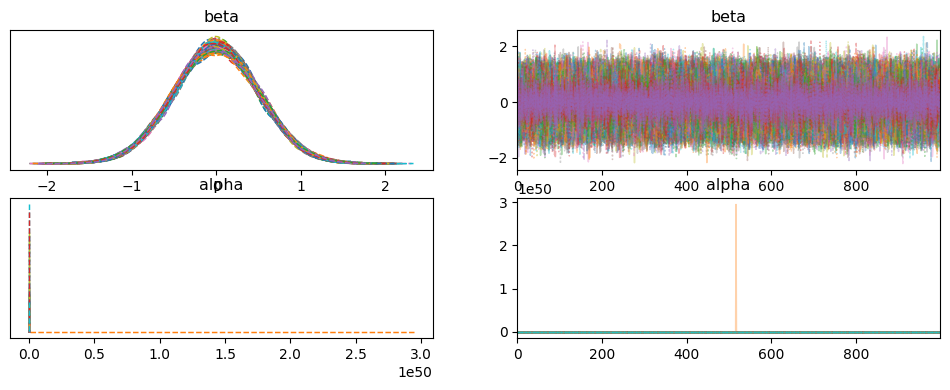

In [ ]:

az.plot_trace(def_trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
def_summary = az.summary(def_trace, var_names=["beta"], round_to=2)
def_summary

In [ ]:
def_feat_importance = get_feature_importance(def_trace,def_mid_cols)#
def_feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
147,xGBuildup_1_ewm,0.016283,positive,0.513833,-0.925172,0.961765
44,tackles_5_ewm,0.014667,positive,0.509500,-0.960861,0.970563
16,expected_goals_conceded_3_ewm,0.012707,negative,0.511000,-0.964919,0.929707
46,npxG_3_ewm,0.012236,positive,0.506500,-0.938280,0.957609
95,minutes_5_ewm,0.011026,negative,0.505667,-0.936404,0.938919
...,...,...,...,...,...,...
26,expected_assists_5_ewm,0.000236,negative,0.501667,-0.931561,0.948550
59,strength_defence_away_5_ewm,0.000213,negative,0.501500,-0.911698,0.947543
45,npxG_1_ewm,0.000087,negative,0.499833,-0.913923,0.957767
18,yellow_cards_1_ewm,0.000073,negative,0.500333,-0.961486,0.948914


In [ ]:
def_feat_importance[def_feat_importance['significance_pd'] > .52]

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi


## MID


In [16]:
mid_picks_df = hist_manager[hist_manager['round']< gw]['mid_picks']
X_mid, M_mid, Y_mid, players_mid = prepare_data_matrices(mid_data, mid_picks_df, def_mid_cols)

mid_trace, mid_scaler = estimate_opponent_betas_with_market_prior(X_mid, M_mid, Y_mid, use_gpu=True)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.48,7
,2000,0,0.48,7
,2000,0,0.47,7
,2000,0,0.48,7
,2000,0,0.48,7
,2000,0,0.48,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.00,0.50,-0.95,0.95,0.01,0.01,7732.61,4345.07,1.0
beta[1],-0.01,0.50,-0.96,0.90,0.01,0.01,8458.84,4522.14,1.0
beta[2],-0.00,0.49,-0.94,0.90,0.01,0.01,8050.23,3993.63,1.0
beta[3],-0.00,0.50,-0.94,0.94,0.01,0.01,7940.46,4258.51,1.0
beta[4],0.01,0.50,-0.94,0.92,0.01,0.01,7524.60,4510.68,1.0
...,...,...,...,...,...,...,...,...,...
beta[150],-0.01,0.49,-0.94,0.90,0.01,0.01,7465.54,4538.44,1.0
beta[151],0.00,0.50,-0.97,0.95,0.01,0.01,7918.57,3798.56,1.0
beta[152],-0.00,0.49,-0.92,0.93,0.01,0.01,8163.22,3961.43,1.0
beta[153],-0.01,0.49,-0.93,0.92,0.01,0.01,7518.37,4262.27,1.0


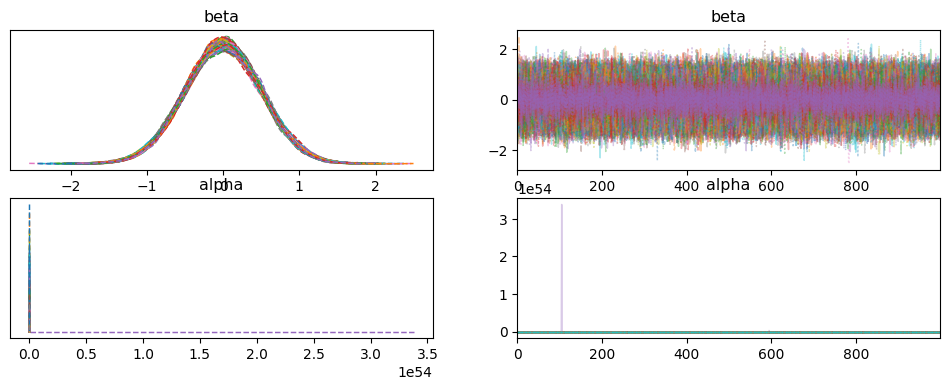

In [17]:

az.plot_trace(mid_trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
mid_summary = az.summary(mid_trace, var_names=["beta"], round_to=2)
mid_summary

In [18]:
mid_feat_importance = get_feature_importance(mid_trace,def_mid_cols)#
mid_feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
42,tackles_1_ewm,0.016258,negative,0.508000,-0.970145,0.916221
69,threat_1_ewm,0.015708,negative,0.516167,-0.962537,0.911316
33,expected_goal_involvements_1_ewm,0.014698,negative,0.511000,-0.959602,0.910927
6,percenatge_net_transfers,0.014428,negative,0.513667,-0.932251,0.924549
82,transfers_in_3_ewm,0.013002,positive,0.516167,-0.929959,0.951317
...,...,...,...,...,...,...
91,selected_by_percent_3_ewm,0.000255,negative,0.504833,-0.912436,0.917192
154,was_home_True,0.000182,negative,0.503833,-0.933940,0.918455
133,transfers_out_3_ewm,0.000103,negative,0.502500,-0.942144,0.953327
51,goals_conceded_1_ewm,0.000040,positive,0.499167,-0.951370,0.924449


In [20]:
mid_feat_importance[mid_feat_importance['significance_pd'] > .5]

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
42,tackles_1_ewm,0.016258,negative,0.508000,-0.970145,0.916221
69,threat_1_ewm,0.015708,negative,0.516167,-0.962537,0.911316
33,expected_goal_involvements_1_ewm,0.014698,negative,0.511000,-0.959602,0.910927
6,percenatge_net_transfers,0.014428,negative,0.513667,-0.932251,0.924549
82,transfers_in_3_ewm,0.013002,positive,0.516167,-0.929959,0.951317
...,...,...,...,...,...,...
138,strength_1_ewm,0.000432,negative,0.502167,-0.937827,0.921956
91,selected_by_percent_3_ewm,0.000255,negative,0.504833,-0.912436,0.917192
154,was_home_True,0.000182,negative,0.503833,-0.933940,0.918455
133,transfers_out_3_ewm,0.000103,negative,0.502500,-0.942144,0.953327


## FWD


In [42]:
fwd_picks_df = hist_manager[hist_manager['round']< gw]['fwd_picks']
X_fwd, M_fwd, Y_fwd, players_fwd = prepare_data_matrices(fwd_data, fwd_picks_df, fwd_cols)

fwd_trace, fwd_scaler = estimate_opponent_betas_with_market_prior(X_fwd, M_fwd, Y_fwd, use_gpu=True)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.60,7
,2000,0,0.62,7
,2000,0,0.62,7
,2000,0,0.61,7
,2000,0,0.59,7
,2000,0,0.60,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-0.00,0.50,-0.96,0.91,0.0,0.01,15657.67,3440.86,1.0
beta[1],-0.00,0.50,-0.97,0.92,0.0,0.01,15666.76,4801.70,1.0
beta[2],-0.00,0.50,-0.92,0.95,0.0,0.01,14284.38,3974.38,1.0
beta[3],-0.01,0.51,-0.94,0.98,0.0,0.01,14553.16,4436.11,1.0
beta[4],0.00,0.50,-0.91,0.96,0.0,0.01,16319.80,4234.79,1.0
...,...,...,...,...,...,...,...,...,...
beta[56],0.00,0.51,-1.01,0.93,0.0,0.01,18045.47,4430.45,1.0
beta[57],0.00,0.50,-0.91,0.94,0.0,0.01,16237.02,4258.03,1.0
beta[58],0.00,0.52,-0.96,1.02,0.0,0.01,14448.97,3697.40,1.0
beta[59],0.01,0.49,-0.91,0.90,0.0,0.01,14468.29,4401.44,1.0


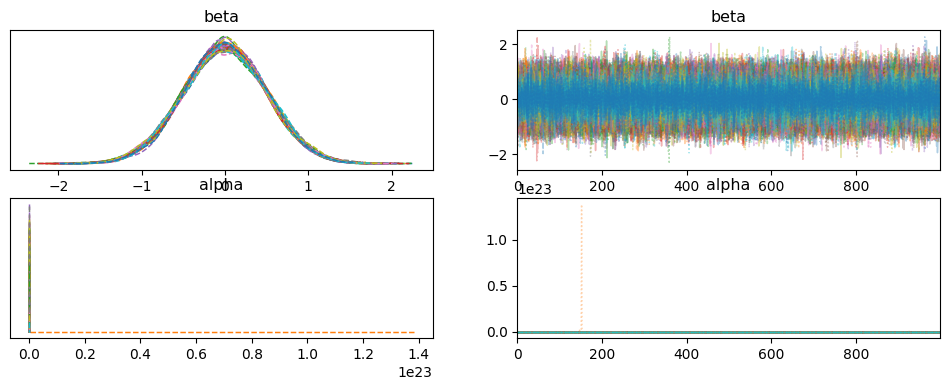

In [45]:

az.plot_trace(fwd_trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
fwd_summary = az.summary(fwd_trace, var_names=["beta"], round_to=2)
fwd_summary

In [46]:
fwd_feat_importance = get_feature_importance(fwd_trace,fwd_cols)#
fwd_feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
13,cbitr_ewm_90,0.010340,positive,0.513667,-0.923283,0.939760
29,shots_5_ewm,0.009573,negative,0.504167,-0.968241,0.958893
34,selected_by_percent_5_ewm,0.008892,positive,0.503167,-0.885289,0.912268
59,was_home_False,0.008009,positive,0.507500,-0.907114,0.914244
28,threat_5_ewm,0.007954,negative,0.502167,-0.949753,0.927338
...,...,...,...,...,...,...
56,opp_elo,0.000581,positive,0.499167,-0.980879,0.965589
2,transfers_in,0.000549,negative,0.499000,-0.958691,0.916999
25,xG_5_ewm,0.000514,negative,0.505500,-0.952515,0.966081
5,ownership_change,0.000495,positive,0.501667,-0.943733,0.931125


In [ ]:
mid_feat_importance[mid_feat_importance['significance_pd'] > .5]

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
128,pts_bonus_5_ewm,0.019882,positive,0.515167,-0.888537,0.946970
134,transfers_out_5_ewm,0.014703,positive,0.514000,-0.937050,0.937678
106,form_3_ewm,0.012831,positive,0.516167,-0.940486,0.954145
144,strength_defence_home_1_ewm,0.012808,positive,0.510167,-0.926034,0.944294
108,clean_sheets_1_ewm,0.011902,negative,0.506833,-0.922244,0.899170
...,...,...,...,...,...,...
152,opp_strength,0.000376,negative,0.507000,-0.918536,0.903564
97,red_cards_3_ewm,0.000204,positive,0.503500,-0.940369,0.952685
142,selected_3_ewm,0.000089,positive,0.500500,-0.925730,0.900271
32,goals_5_ewm,0.000080,negative,0.505000,-0.935080,0.924300


# Before


In [12]:
working_feats = ['draw_prob',
 'elo',
 'starts_1_ewm',
 'was_home_True',
 'win_prob',
 'clearances_blocks_interceptions_1_ewm',
 'influence_1_ewm',
 'minutes_1_ewm',
 'transfers_out',
 'expected_goal_involvements_1_ewm',
 'team_a_difficulty',
 'percenatge_net_transfers_1_ewm',
 'xGBuildup_1_ewm',
 'value_1_ewm',
 'xG_1_ewm',
 'ownership_change',
 'was_home_False',
 'expected_goals_1_ewm',
 'goals_1_ewm',
 'xA_1_ewm',
 'npg_1_ewm',
 'saves_1_ewm',
 'cbitr_ewm_probability',
 'assists_1_ewm',
 'tackles_1_ewm']

In [13]:
X, M,Y, players = prepare_data_matrices(active_data_, history_df, working_feats)#feats)

In [14]:
trace, scaler = estimate_opponent_betas_with_market_prior(X, Y, M, use_gpu=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.25,31
,2000,0,0.28,31
,2000,0,0.24,31
,2000,0,0.27,23
,2000,0,0.26,15
,2000,0,0.27,31


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.99,0.39,0.25,1.68,0.00,0.00,8396.69,4863.50,1.0
beta[1],1.25,0.44,0.43,2.08,0.00,0.01,7835.56,5015.55,1.0
beta[2],0.82,0.40,0.11,1.60,0.00,0.01,6514.40,4443.72,1.0
beta[3],0.41,0.36,-0.28,1.08,0.01,0.01,4802.63,4384.58,1.0
beta[4],0.38,0.28,-0.15,0.91,0.00,0.00,7610.81,4801.33,1.0
beta[5],-0.45,0.23,-0.91,-0.04,0.00,0.00,5163.68,4699.10,1.0
beta[6],0.08,0.31,-0.47,0.67,0.01,0.00,2957.83,3985.60,1.0
beta[7],0.79,0.38,0.12,1.55,0.00,0.00,6623.52,4802.26,1.0
beta[8],0.36,0.06,0.25,0.48,0.00,0.00,7898.02,5117.96,1.0
beta[9],0.17,0.26,-0.29,0.69,0.01,0.00,2335.88,3401.04,1.0


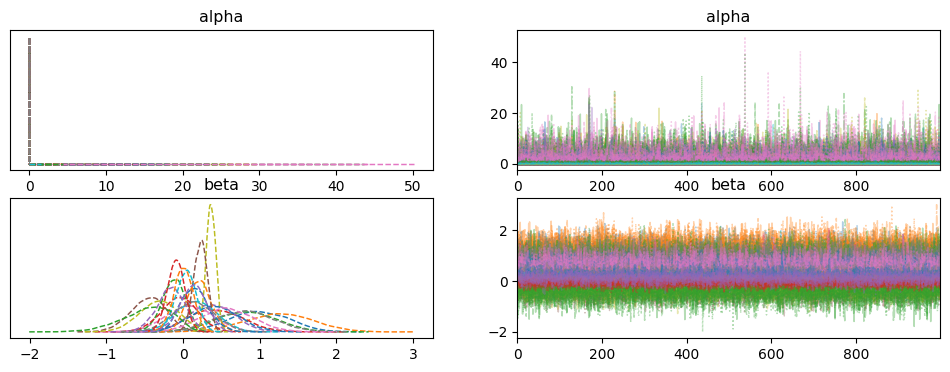

In [15]:
# trace_gk
az.plot_trace(trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace, var_names=["beta"], round_to=2)
summary

In [16]:
feat_importance = get_feature_importance(trace,working_feats)#['value', 'selected_by_percent', 'transfers_in_3_ewm', 'form_3_ewm', 'ict_index_3_ewm', 'team_h_difficulty', 'win_prob', 'elo'])
feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
1,elo,1.251699,positive,0.997833,0.418525,2.065368
0,draw_prob,0.990386,positive,0.994667,0.265915,1.702050
2,starts_1_ewm,0.823325,positive,0.979000,0.057051,1.561352
7,minutes_1_ewm,0.793593,positive,0.982333,0.092149,1.523528
16,was_home_False,0.566722,positive,0.950000,-0.077445,1.225563
22,cbitr_ewm_probability,0.472486,negative,0.952333,-1.151910,0.038220
5,clearances_blocks_interceptions_1_ewm,0.454852,negative,0.979333,-0.906080,-0.035737
3,was_home_True,0.414143,positive,0.878500,-0.273956,1.102144
10,team_a_difficulty,0.405093,positive,0.900167,-0.178645,0.999621
4,win_prob,0.378349,positive,0.911000,-0.151797,0.909616


In [17]:
working_feats_ = feat_importance[feat_importance['significance_pd'] > .7]
working_feats_

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
1,elo,1.251699,positive,0.997833,0.418525,2.065368
0,draw_prob,0.990386,positive,0.994667,0.265915,1.702050
2,starts_1_ewm,0.823325,positive,0.979000,0.057051,1.561352
7,minutes_1_ewm,0.793593,positive,0.982333,0.092149,1.523528
16,was_home_False,0.566722,positive,0.950000,-0.077445,1.225563
22,cbitr_ewm_probability,0.472486,negative,0.952333,-1.151910,0.038220
5,clearances_blocks_interceptions_1_ewm,0.454852,negative,0.979333,-0.906080,-0.035737
3,was_home_True,0.414143,positive,0.878500,-0.273956,1.102144
10,team_a_difficulty,0.405093,positive,0.900167,-0.178645,0.999621
4,win_prob,0.378349,positive,0.911000,-0.151797,0.909616


## Get Stochastic Stats


In [18]:
stochastic_stats = get_opponent_stochastic_stats(active_data_next_, trace, working_feats, scaler)
sigma = estimate_player_covariance(active_data_, active_data_next_['fpl_id'].values)

mean = stochastic_stats['mean']
variance = stochastic_stats['variance']
cov_vector = stochastic_stats['cov_vector']
simulated_scores = stochastic_stats['simulated_scores']

stochastic_stats

Estimating covariance for 304 players using Ledoit-Wolf...


{'mean': np.float64(64.526),
 'variance': np.float64(40.821064),
 'cov_vector': array([-1.39265265e-01,  9.32482482e-01, -5.00350350e-01, -4.40016016e-01,
        -7.54074074e-02, -3.51211211e-02, -4.58258258e-03, -9.65985986e-02,
        -9.48748749e-03, -4.25625626e-03, -4.04264264e-02, -3.04126126e-01,
        -1.70970971e-03,  2.20076076e-01, -4.83963964e-02,  4.55095095e-02,
        -1.22358358e-01, -1.79143143e-01,  2.36936937e-02,  1.27527528e-03,
         1.84884885e-02, -2.36084084e-01, -1.33653654e-02,  0.00000000e+00,
        -3.14654655e-02,  0.00000000e+00, -1.44590591e-01,  4.47327327e-02,
         3.34272272e-01,  2.67947948e-02,  0.00000000e+00,  5.12376376e-01,
         0.00000000e+00, -1.27207207e-02, -8.23423423e-03, -3.96176176e-02,
        -5.83183183e-03, -1.68988989e-02, -1.72082082e-01,  1.17517518e-03,
        -1.81021021e-02,  0.00000000e+00, -1.76736737e-02,  0.00000000e+00,
        -4.65665666e-03, -1.28388388e-02,  0.00000000e+00, -2.31349349e-01,
        -

In [20]:
my_hist_manager

,picks,manager_id,round,total_points,points_on_bench
0,"[{'element': 220, 'position': 1, 'multiplier':...",438682,1,59,12
1,"[{'element': 220, 'position': 1, 'multiplier':...",438682,2,41,13
2,"[{'element': 220, 'position': 1, 'multiplier':...",438682,3,59,21
3,"[{'element': 253, 'position': 1, 'multiplier':...",438682,4,67,5
4,"[{'element': 101, 'position': 1, 'multiplier':...",438682,5,50,2
5,"[{'element': 101, 'position': 1, 'multiplier':...",438682,6,72,14
6,"[{'element': 101, 'position': 1, 'multiplier':...",438682,7,67,10
7,"[{'element': 253, 'position': 1, 'multiplier':...",438682,8,76,10
8,"[{'element': 101, 'position': 1, 'multiplier':...",438682,9,71,7
9,"[{'element': 253, 'position': 1, 'multiplier':...",438682,10,83,6


In [23]:
optimizer_data = active_data_next_[['fpl_id', 'xP', 'value', 'position', 'team_id']].copy()
optimizer_data.loc[:, 'cov_with_opp'] = cov_vector
optimizer_data

current_squad_ids = my_hist_manager[my_hist_manager['round'] == gw]['selections'].values.tolist()[0]

# Optimizer


In [85]:

def solve_fpl_strategic_h2h(
    player_data,
    current_squad_ids,
    opponent_expected_score,
    opponent_variance,
    covariance_matrix, # Sigma_delta matrix for all players
    budget,
    free_transfers=1,
    hit_penalty=4,
    lambda_val=0.1,
    mode='favorite' # 'favorite' (minimize variance) or 'underdog' (maximize variance)

):
    """
    Implements the Haugh and Singal (2020) Strategic Framework for FPL H2H.

    Step 1: 15-man Squad Selection (Transfer optimization)
    Step 2: 11-man Lineup Selection (Strategic positioning vs Opponent)
    """

    # --- Pre-filtering to satisfy Gurobi License Limits ---
    # We must keep players in our current squad, then fill with top xP prospects.
    max_players=110
    current_squad_mask = player_data.index.isin(current_squad_ids)
    prospects = player_data[~current_squad_mask].sort_values('xP', ascending=False).head(max_players - len(current_squad_ids))

    filtered_df = pd.concat([player_data[current_squad_mask], prospects])

    # Slice the covariance matrix to match the filtered players
    original_indices = player_data.index.tolist()
    filtered_indices = filtered_df.index.tolist()

    # Get the integer positions of filtered players in the original matrix
    pos_map = [original_indices.index(idx) for idx in filtered_indices]
    filtered_sigma = covariance_matrix[np.ix_(pos_map, pos_map)]

    # Re-assign for the model logic
    player_data = filtered_df
    covariance_matrix = filtered_sigma
    players = filtered_indices


    model = gp.Model("FPL_Strategic_H2H")

    # --- Variables ---
    # w[i] = 1 if player i is in the 15-man squad
    # s[i] = 1 if player i is in the starting 11
    # c[i] = 1 if player i is the captain
    players = player_data.index.tolist()
    num_players = len(players)

    print('players:', len(players))

    w = model.addVars(players, vtype=GRB.BINARY, name="squad")
    s = model.addVars(players, vtype=GRB.BINARY, name="starter")

    # --- Constraints: 15-man Squad ---
    model.addConstr(gp.quicksum(w[i] for i in players) == 15, "squad_size")
    model.addConstr(gp.quicksum(player_data.loc[i, 'value'] * w[i] for i in players) <= budget, "budget")

    # Positional constraints for squad
    for pos, count in [('GK', 2), ('DEF', 5), ('MID', 5), ('FWD', 3)]:
        model.addConstr(gp.quicksum(w[i] for i in players if player_data.loc[i, 'position'] == pos) == count, f"squad_{pos}")

    # Team constraint (max 3 per PL team)
    teams = player_data['team_id'].unique()
    for team in teams:
        model.addConstr(gp.quicksum(w[i] for i in players if player_data.loc[i, 'team_id'] == team) <= 3, f"team_limit_{team}")

    # --- Constraints: Starting 11 ---
    # Starter must be in squad
    for i in players:
        model.addConstr(s[i] <= w[i], f"starter_in_squad_{i}")

    model.addConstr(gp.quicksum(s[i] for i in players) == 11, "starter_count")

    # Formation constraints
    model.addConstr(gp.quicksum(s[i] for i in players if player_data.loc[i, 'position'] == 'GK') == 1, "start_gk")
    model.addConstr(gp.quicksum(s[i] for i in players if player_data.loc[i, 'position'] == 'DEF') >= 3, "min_def")
    model.addConstr(gp.quicksum(s[i] for i in players if player_data.loc[i, 'position'] == 'FWD') >= 1, "min_fwd")

    # --- Transfer Penalty Logic ---
    # Number of transfers = 15 - (players kept from old squad)

    in_current = {i: (1 if i in current_squad_ids else 0) for i in players}

    diff = model.addVar(vtype=GRB.INTEGER, name="num_transfers")

    # transfers = 15 - sum(w[i] * in_current[i])
    model.addConstr(diff == 15 - gp.quicksum(w[i] * in_current[i] for i in players))

    # USER REQUEST: Hard limit to maximum 2 transfers
    model.addConstr(diff <= 4, "hard_transfer_limit")

    # Penalty calculation (simplification: hits = max(0, diff - free_transfers))
    hits = model.addVar(vtype=GRB.INTEGER, name="hits")
    model.addConstr(hits >= diff - free_transfers)
    model.addConstr(hits >= 0)

    # --- Objective Function (The Strategic Core) ---
    # Expected Return: sum(s[i] * xP[i]) - hits * 4
    expected_return = gp.quicksum(player_data.loc[i, 'xP'] * s[i] for i in players) - hits * hit_penalty

    # Variance Term: w.T * Sigma * w
    # Note: In H2H, variance is Var(MyScore - OpponentScore)
    # This involves your team variance and the covariance with opponent
    # For Gurobi, we model the quadratic team variance part
    team_variance = gp.quicksum(
        s[i] * s[j] * covariance_matrix[idx_i][idx_j]
        for idx_i, i in enumerate(players)
        for idx_j, j in enumerate(players)
    )

    # Covariance with opponent (modeled as a vector of cov(player_i, opponent_team))
    # You calculate this offline by summing cov(player_i, player_k) for all k in opponent's predicted team
    # We'll assume player_data has a column 'cov_with_opp'
    opp_covariance = gp.quicksum(player_data.loc[i, 'cov_with_opp'] * s[i] for i in players)

    # Full H2H Variance: Var(Team) + Var(Opp) - 2*Cov(Team, Opp)
    # Since Var(Opp) is constant, we optimize: Var(Team) - 2*Cov(Team, Opp)
    h2h_variance_component = team_variance - 2 * opp_covariance

    if mode == 'favorite':
        # Maximize (Mean - Lambda * Variance) -> Be safe, minimize "swing"
        model.setObjective(expected_return - lambda_val * h2h_variance_component, GRB.MAXIMIZE)
    else:
        # Maximize (Mean + Lambda * Variance) -> Seek high "swing" to catch up
        model.setObjective(expected_return + lambda_val * h2h_variance_component, GRB.MAXIMIZE)

    # Solve
    model.setParam('OutputFlag', 1)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        selected_squad = [i for i in players if w[i].X > 0.5]
        selected_lineup = [i for i in players if s[i].X > 0.5]
        return {
            "squad": selected_squad,
            "lineup": selected_lineup,
            "expected_score": expected_return.getValue() + (hits.X * hit_penalty),
            "hits": hits.X
        }
    else:
        return None

results = solve_fpl_strategic_h2h(optimizer_data, current_squad_ids, mean, variance, sigma, 100, mode='underdog')
results

players: 96
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 130 rows, 194 columns and 733 nonzeros (Max)
Model fingerprint: 0x49e79e97
Model has 97 linear objective coefficients
Model has 4181 quadratic objective terms
Variable types: 0 continuous, 194 integer (192 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [3e+00, 1e+01]
  QObjective range [2e-04, 3e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+02]

Presolve removed 8 rows and 0 columns
Presolve time: 0.00s

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 2 available processors)

Solution count 0
No other solutions better than -1e+100

Model is infeasible
Best objective -, best boun

In [83]:
results

In [ ]:
squad  = pd.DataFrame([optimizer_data.loc[i] for i in results['squad']])
lineup = [optimizer_data.loc[i]['fpl_id'] for i in results['lineup']]
lineup

squad['starter'] = squad.apply(lambda row: row['fpl_id'] in lineup, axis=1)
squad = squad.merge( data_next[['fpl_id', 'fpl_name', 'team']], on='fpl_id', how='left')
squad[['fpl_id', 'fpl_name', 'position', 'team', 'starter']]

TypeError: 'NoneType' object is not subscriptable

In [79]:
curr_squad = data_next[data_next['fpl_id'].isin(current_squad_ids)]
curr_squad[[ 'fpl_id', 'fpl_name', 'position', 'team']]

,fpl_id,fpl_name,position,team
638,72.0,Senesi,DEF,Bournemouth
727,82.0,Semenyo,MID,Bournemouth
905,101.0,Kelleher,GK,Brentford
1066,119.0,Mbeumo,MID,Man Utd
1280,145.0,De Cuyper,DEF,Brighton
2189,253.0,Henderson,GK,Crystal Palace
2212,256.0,Muñoz,DEF,Crystal Palace
2320,266.0,Eze,MID,Arsenal
2444,283.0,Mateta,FWD,Crystal Palace
2756,316.0,Robinson,DEF,Fulham


In [87]:
new_ids = squad['fpl_id'].values.tolist()
curr_ids = curr_squad['fpl_id'].values.tolist()

len(set(new_ids) -  set(curr_ids))

13